# EDA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Импортируем файл для анализа

In [2]:
file_path = r"C:\Users\Кика\Desktop\hotel_bookings.csv"
df = pd.read_csv(file_path)

Выведем заголовки файла

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Узнаем количество строк и столбцов датасета

In [4]:
df.shape

(119390, 32)

В таблице 32 столбца - признака, содержащих информацию о бронировании отеля

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

Таблица содержит следующие данные. 

In [6]:
feature_descriptions = {
    "hotel": "Тип отеля (Resort Hotel или City Hotel)",
    "is_canceled": "Было ли бронирование отменено (1 — да, 0 — нет)",
    "lead_time": "Количество дней между датой бронирования и датой заезда",
    "arrival_date_year": "Год заезда",
    "arrival_date_month": "Месяц заезда",
    "arrival_date_week_number": "Номер недели в году для даты заезда",
    "arrival_date_day_of_month": "День месяца заезда",
    "stays_in_weekend_nights": "Количество ночей в выходные (суббота или воскресенье)",
    "stays_in_week_nights": "Количество ночей с понедельника по пятницу",
    "adults": "Количество взрослых",
    "children": "Количество детей",
    "babies": "Количество младенцев",
    "meal": "Тип питания (например, BB — только завтрак)",
    "country": "Страна проживания гостя",
    "market_segment": "Сегмент рынка (например, Online TA, Corporate)",
    "distribution_channel": "Канал бронирования",
    "is_repeated_guest": "Повторный гость (1 — да, 0 — нет)",
    "previous_cancellations": "Количество предыдущих отмен",
    "previous_bookings_not_canceled": "Количество предыдущих бронирований без отмены",
    "reserved_room_type": "Тип номера, указанный при бронировании",
    "assigned_room_type": "Фактически назначенный тип номера",
    "booking_changes": "Количество изменений бронирования",
    "deposit_type": "Тип депозита (No Deposit, Non Refund и т.д.)",
    "agent": "ID агента, оформившего бронирование",
    "company": "ID компании, оформившей бронирование",
    "days_in_waiting_list": "Количество дней в списке ожидания до подтверждения",
    "customer_type": "Тип клиента (Transient, Contract и др.)",
    "adr": "Средняя суточная ставка (Average Daily Rate)",
    "required_car_parking_spaces": "Количество запрошенных парковочных мест",
    "total_of_special_requests": "Общее количество специальных запросов",
    "reservation_status": "Текущий статус бронирования (Canceled, Check-Out и др.)",
    "reservation_status_date": "Дата, когда был установлен статус бронирования"
}

In [7]:
feature_info = pd.DataFrame({
    "Признак": list(feature_descriptions.keys()),
    "Описание": list(feature_descriptions.values())
})

In [8]:
feature_info

,Признак,Описание
0,hotel,Тип отеля (Resort Hotel или City Hotel)
1,is_canceled,"Было ли бронирование отменено (1 — да, 0 — нет)"
2,lead_time,Количество дней между датой бронирования и дат...
3,arrival_date_year,Год заезда
4,arrival_date_month,Месяц заезда
5,arrival_date_week_number,Номер недели в году для даты заезда
6,arrival_date_day_of_month,День месяца заезда
7,stays_in_weekend_nights,Количество ночей в выходные (суббота или воскр...
8,stays_in_week_nights,Количество ночей с понедельника по пятницу
9,adults,Количество взрослых


Выведем основную статистическую информацию по датасету 

In [9]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Как мы видим, в столбцах children, agent и company есть пропущенные значения. Нужно их обработать. Также посмотрим какие есть признаки с типом object и оценим возможности для кодирования.

In [10]:
df.describe(include="object")

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


Как мы видим, кодирование категориальных признаков ничего нам не принесет

Удалим строки с пропущенными значениями и столбцы с большим количеством пропусков, а также выбросы

In [11]:
# очистка данных
df_cleaned = df.dropna(subset= ["children"])
df_cleaned = df_cleaned.drop(columns=['agent', 'company']) 

# Только эти столбцы считаем «чувствительными к выбросам»
key_numeric = ['adr', 'lead_time', 'total_of_special_requests']

for col in key_numeric:
    if col in df_cleaned.columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower) & (df_cleaned[col] <= upper)]


Выведем форму датасета после манипуляций

In [12]:
df_cleaned.shape

(110079, 30)

Мы убрали два признака и строки с выбросами и пропущенными значениями

## Анализ распределений

Рассмотрим числовые признаки

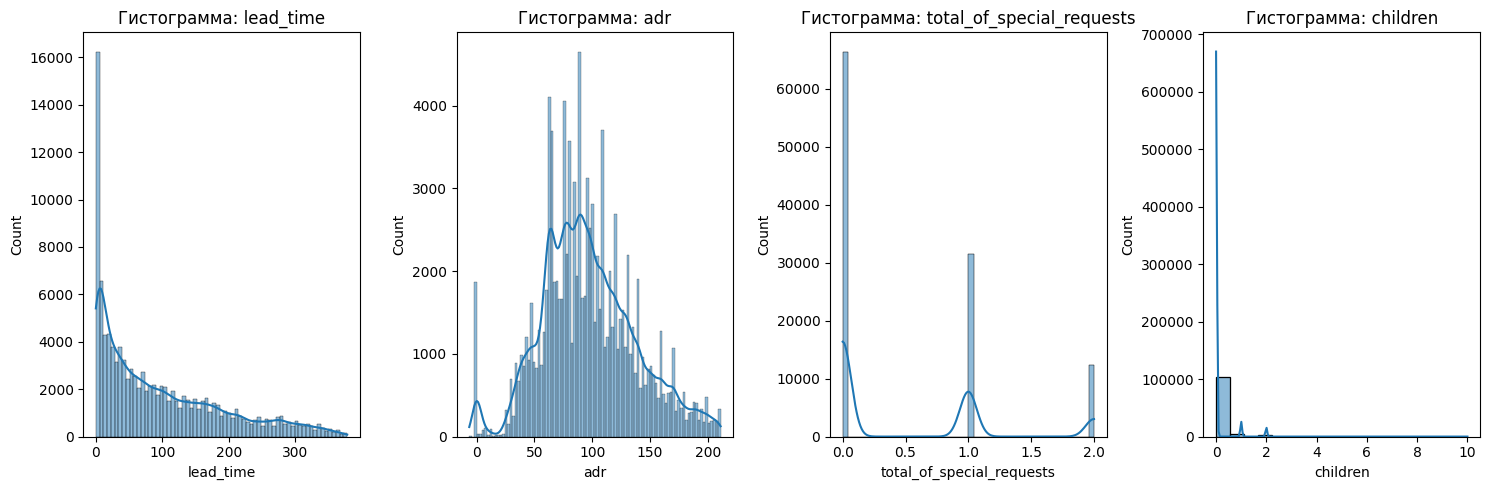

In [14]:
# список признаков для визуализации
features = ['lead_time', 'adr', 'total_of_special_requests', 'children']

# создаём окно с подграфиками: 1 строка, 3 столбца
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# строим гистограмму для каждого признака
for i, col in enumerate(features):
    sns.histplot(data=df_cleaned, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Гистограмма: {col}')

# автоматическое выравнивание, чтобы подписи не накладывались
plt.tight_layout()

Рассмотрим категориальные признаки

<Axes: xlabel='is_canceled', ylabel='count'>

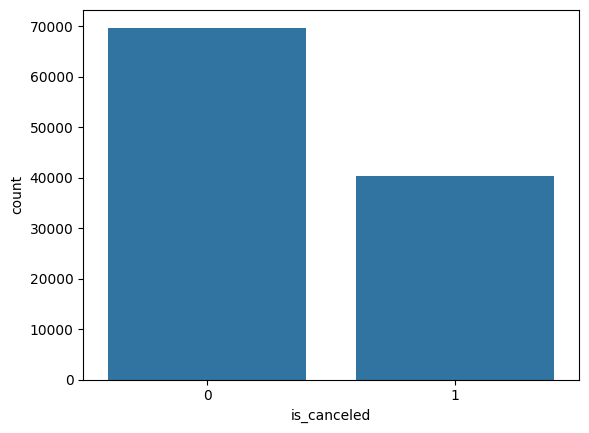

In [15]:

sns.countplot(x= "is_canceled", data= df_cleaned) # распределение по отмене заявки


<Axes: xlabel='customer_type', ylabel='count'>

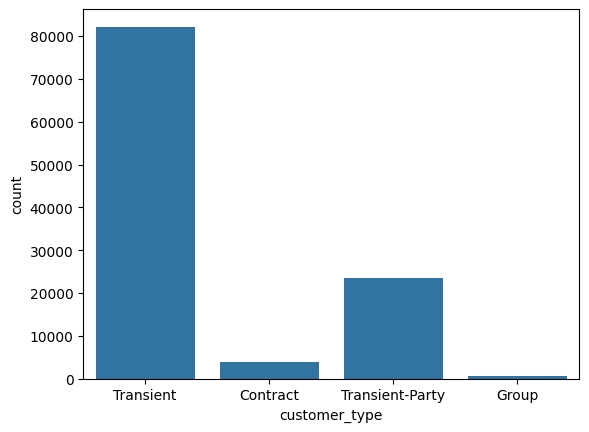

In [16]:
sns.countplot(x= "customer_type", data= df_cleaned) # распределение по типу клиента

<Axes: xlabel='adr'>

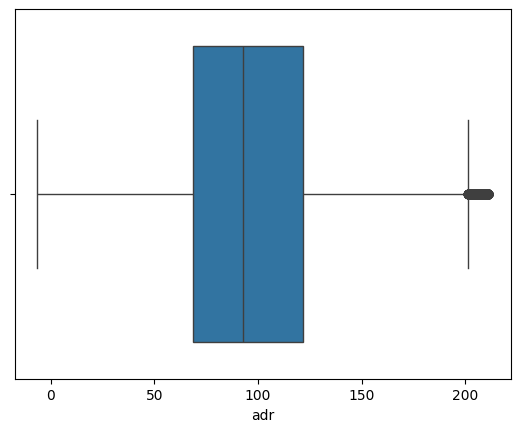

In [17]:
sns.boxplot(x="adr", data=df_cleaned)

## Корреляционный анализ

In [18]:
numeric_col = df_cleaned.select_dtypes(include="number").columns # выбираем столбцы с числовыми данными

Выведем корреляционную матрицу

<Axes: >

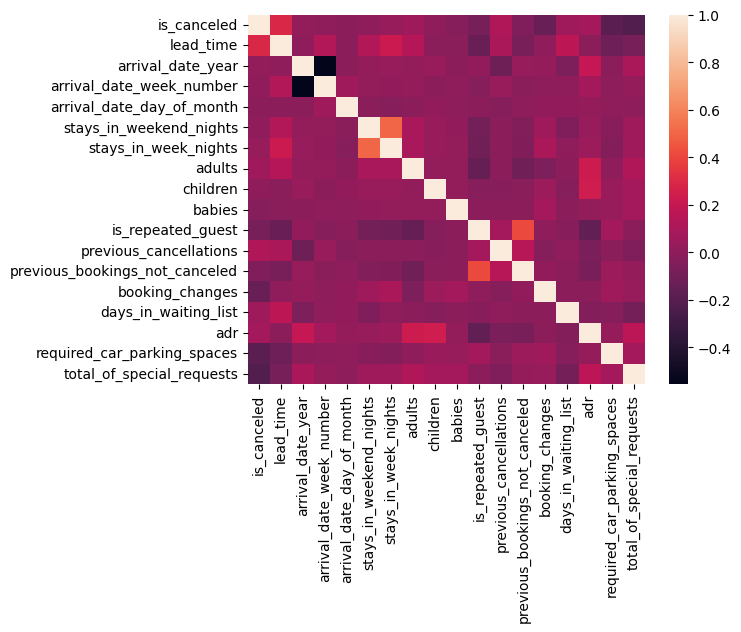

In [19]:
corr_matrix = df_cleaned[numeric_col].corr() # создаем матрицу корреляции
sns.heatmap(corr_matrix) # отображаем корреляционную матрицу

<Axes: >

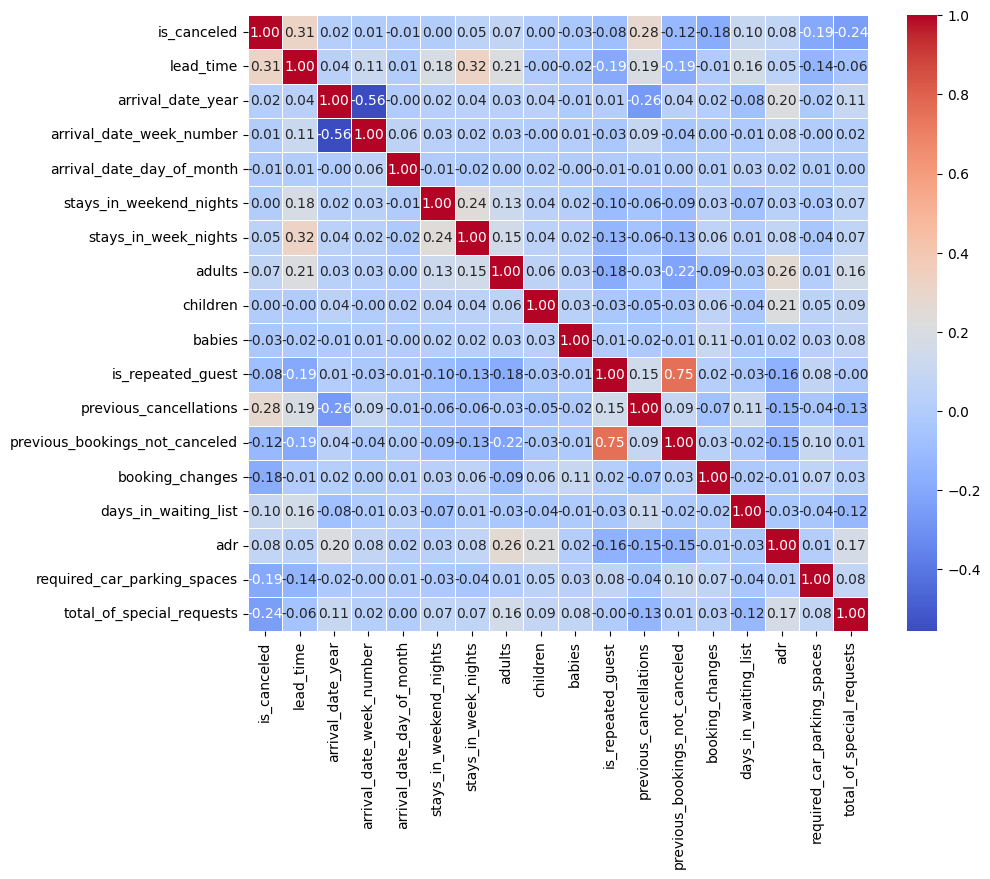

In [20]:
# Расчет корреляционной матрицы с использованием коэффициента Спирмена
spearman_corr = df_cleaned[numeric_col].corr(method='spearman')

# Визуализация корреляционной матрицы Спирмена
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

Как мы видим из матрицы корреляции - сильнокоррелированные данные практически отсутствуют. Стоит выделить отдельные зависимости между adr и children, arrival_date_week_number и arrival_date_year, lead_time и is_cancelled, stays_in_week_nights и stays_in_weekend_nights, is_repeated_guest и previous_booking_not_cancelled.

Стоит отметить коррелированную пару is_repeated_guest и previous_booking_not_cancelled - присутстсвует сильная линейная зависимость между тем что гость забронировал отель снова и что прошлое бронирование не было отменено, а также между временем между бронированием и заселением и маркером было бронирование отменено или же нет.